In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)

df = pd.read_parquet("../data/processed/provinces/master_regional_2009_2025.parquet")
print(df.shape)
print(df.dtypes)
df.head()

(887, 14)
week_start                     datetime64[ns]
calima_proxy_score_regional           float64
calima_proxy_level_regional            object
temp_c_mean                           float64
tmax_c_mean                           float64
tmax_c_max                            float64
tmin_c_mean                           float64
tmin_c_min                            float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
prec_sum                              float64
deaths_week                           float64
deaths_missing_week                     int64
dtype: object


,week_start,calima_proxy_score_regional,calima_proxy_level_regional,temp_c_mean,tmax_c_mean,tmax_c_max,tmin_c_mean,tmin_c_min,humidity_mean,pressure_hpa_mean,wind_ms_mean,prec_sum,deaths_week,deaths_missing_week
0,2009-01-05,0.09750,no_calima,17.202381,20.269048,21.083333,14.138095,12.933333,64.714286,1011.053571,5.057143,7.233333,310.0,0
1,2009-01-12,0.20750,no_calima,17.000000,20.047619,20.866667,13.947619,12.816667,64.111111,1016.531548,6.096032,2.550000,302.0,0
2,2009-01-19,0.09750,no_calima,17.657143,20.478571,22.016667,14.833333,13.550000,70.095238,1017.364286,5.338095,1.566667,328.0,0
3,2009-01-26,0.43625,possible,16.992857,20.166667,22.016667,13.828571,12.166667,66.071429,1011.727381,5.964286,2.366667,266.0,0
4,2009-02-02,0.15500,no_calima,17.359524,20.745238,21.916667,13.971429,12.583333,63.880952,1008.529762,5.426190,10.400000,328.0,0


In [2]:
print(df.shape)
print(f"Período: {df['week_start'].min()} → {df['week_start'].max()}")
print(f"\nNulls:\n{df.isnull().sum()}")
print(f"\nCalima levels:\n{df['calima_proxy_level_regional'].value_counts()}")
print(f"\nDescribe deaths:\n{df['deaths_week'].describe()}")

(887, 14)
Período: 2009-01-05 00:00:00 → 2025-12-29 00:00:00

Nulls:
week_start                     0
calima_proxy_score_regional    0
calima_proxy_level_regional    0
temp_c_mean                    0
tmax_c_mean                    0
tmax_c_max                     0
tmin_c_mean                    0
tmin_c_min                     0
humidity_mean                  0
pressure_hpa_mean              0
wind_ms_mean                   0
prec_sum                       0
deaths_week                    0
deaths_missing_week            0
dtype: int64

Calima levels:
calima_proxy_level_regional
no_calima    599
possible     174
probable      64
intense       50
Name: count, dtype: int64

Describe deaths:
count    887.000000
mean     297.191657
std       50.980072
min      157.000000
25%      258.500000
50%      290.000000
75%      331.000000
max      466.000000
Name: deaths_week, dtype: float64


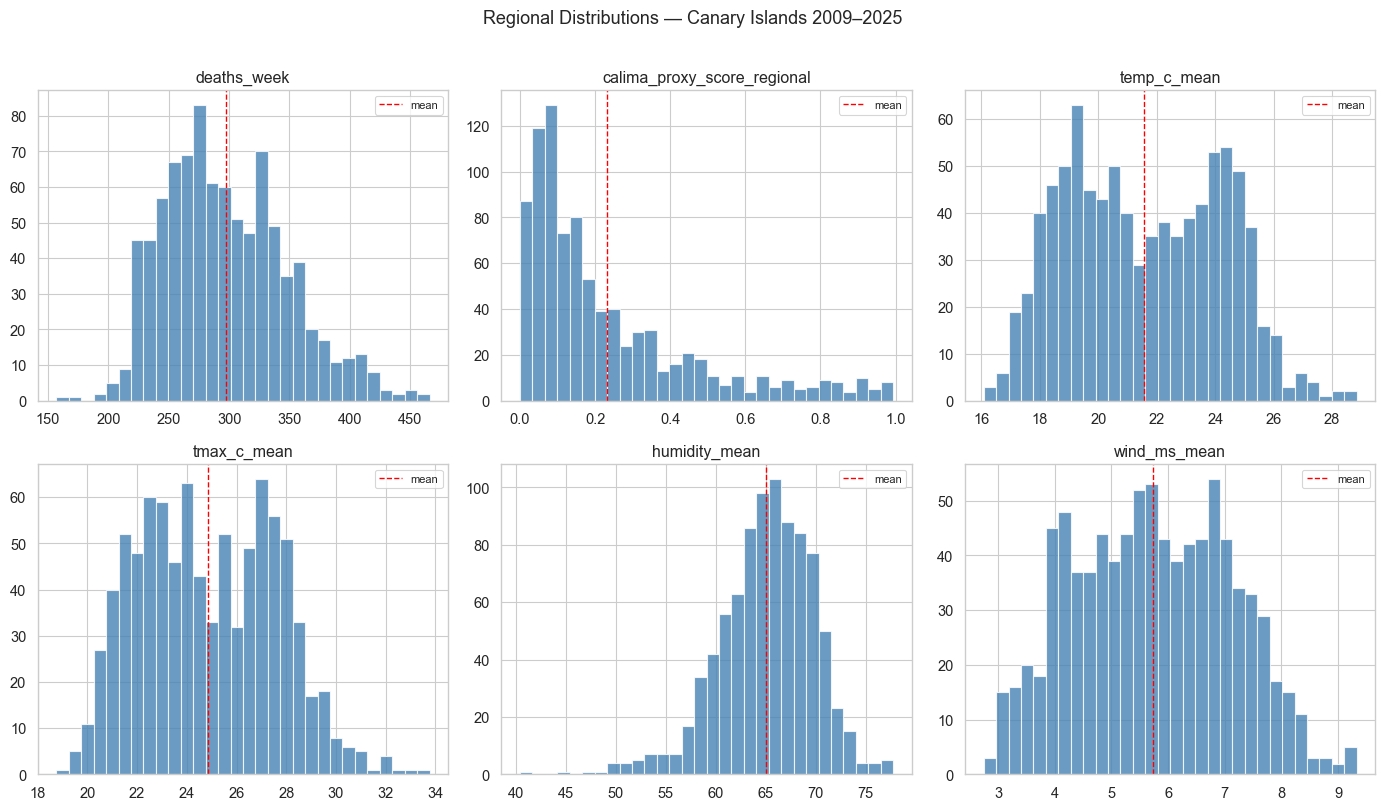

In [3]:
# "C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures"
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

cols = ['deaths_week', 'calima_proxy_score_regional', 'temp_c_mean', 
        'tmax_c_mean', 'humidity_mean', 'wind_ms_mean']

for ax, col in zip(axes.flatten(), cols):
    ax.hist(df[col], bins=30, edgecolor='white', color='steelblue', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='mean')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Regional Distributions — Canary Islands 2009–2025', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../reports/ccaa/figures/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

 ### Observaciones clave:
* deaths_week: right-skewed, cola larga hacia 400–466 (COVID spike esperado)
* calima_proxy_score: fuertemente right-skewed, mayoría near-zero — consistente con 67% no_calima
* temp_c_mean: distribución bimodal clara (~19°C invierno, ~24°C verano) — estacionalidad fuerte, confounder principal
* humidity/wind: aproximadamente normales, sin outliers obvios

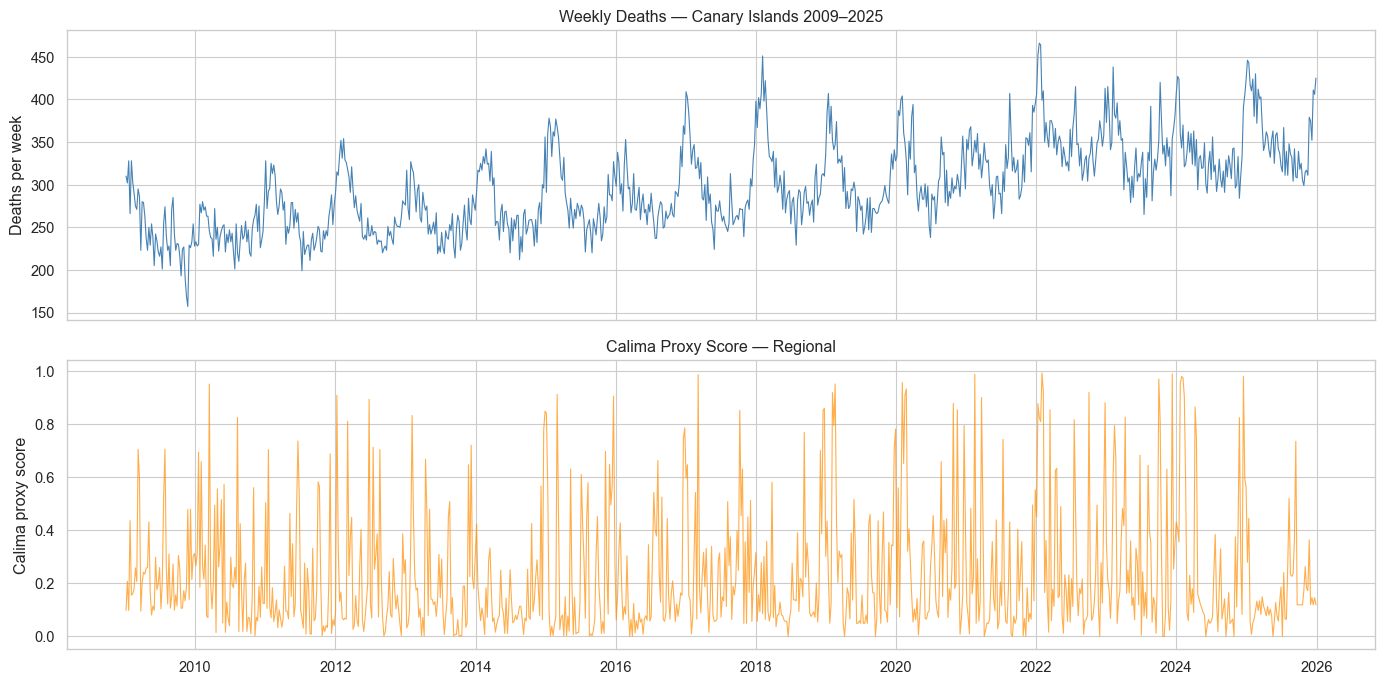

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

df['week_start'] = pd.to_datetime(df['week_start'])

ax1.plot(df['week_start'], df['deaths_week'], linewidth=0.8, color='steelblue')
ax1.set_ylabel('Deaths per week')
ax1.set_title('Weekly Deaths — Canary Islands 2009–2025')

ax2.plot(df['week_start'], df['calima_proxy_score_regional'], linewidth=0.8, color='darkorange', alpha=0.7)
ax2.set_ylabel('Calima proxy score')
ax2.set_title('Calima Proxy Score — Regional')

plt.tight_layout()
plt.savefig(r'C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\fig2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Observaciones clave:
* Deaths: estacionalidad anual clara (picos invierno, valles verano) + tendencia ascendente post-2018 + spike COVID visible ~2020
* Calima: episódico e irregular, sin tendencia temporal obvia — eventos intensos distribuidos a lo largo de todo el período
* Visualmente: no hay co-movimiento obvio entre las dos series — la señal calima-mortality va a necesitar el análisis de lag para salir

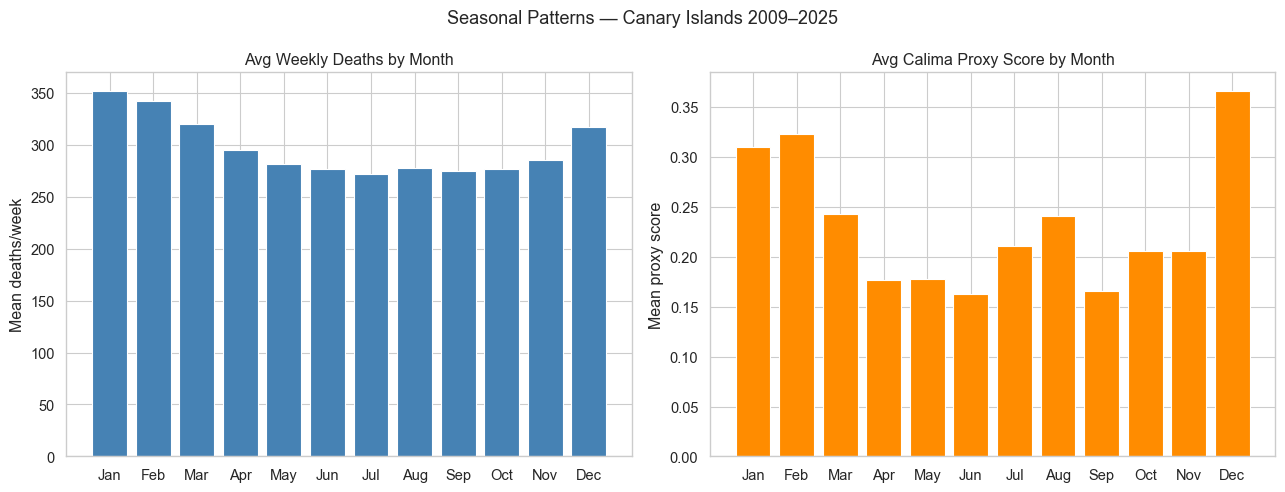

In [5]:
df['month'] = pd.to_datetime(df['week_start']).dt.month
df['year'] = pd.to_datetime(df['week_start']).dt.year

monthly = df.groupby('month')[['deaths_week', 'calima_proxy_score_regional']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax1.bar(monthly.index, monthly['deaths_week'], color='steelblue', edgecolor='white')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_labels)
ax1.set_title('Avg Weekly Deaths by Month')
ax1.set_ylabel('Mean deaths/week')

ax2.bar(monthly.index, monthly['calima_proxy_score_regional'], color='darkorange', edgecolor='white')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(month_labels)
ax2.set_title('Avg Calima Proxy Score by Month')
ax2.set_ylabel('Mean proxy score')

plt.suptitle('Seasonal Patterns — Canary Islands 2009–2025', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\fig3_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## Observaciones críticas:
* Deaths: patrón inverso claro — picos en invierno (Jan ~ 350, Feb ~ 340), mínimo en verano (Jul ~ 270). Clásico exceso de mortalidad invernal.
* Calima: patrón opuesto — picos en invierno y especialmente Dic ( ~ 0.36), mínimo en primavera/verano.
* Implicación para el modelo: calima y deaths comparten estacionalidad invernal → confounding estacional fuerte. El modelo de regresión (Fase 5) necesitará controlar por mes/estación.

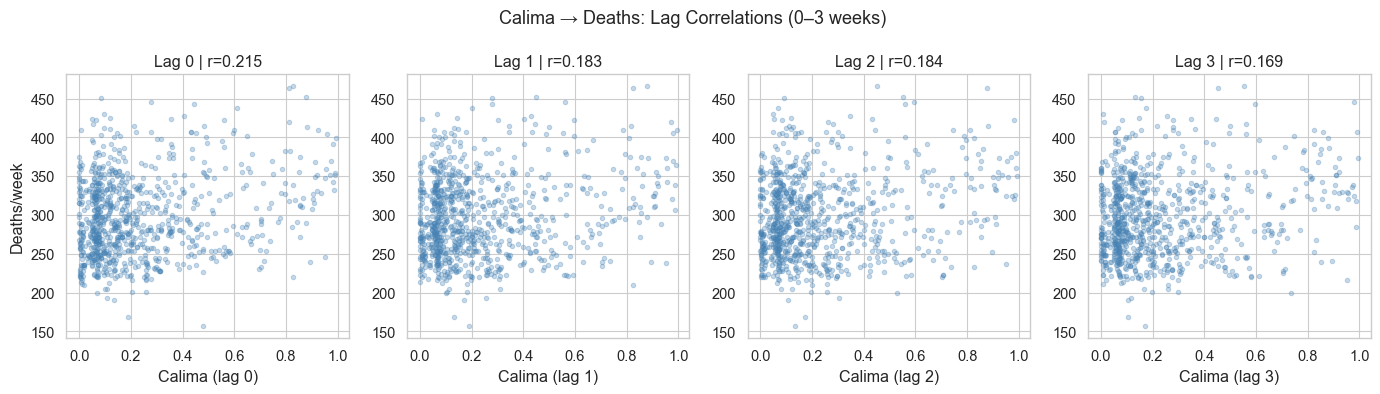

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for lag, ax in enumerate(axes):
    lagged = df['calima_proxy_score_regional'].shift(lag)
    corr = df['deaths_week'].corr(lagged)
    ax.scatter(lagged, df['deaths_week'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(f'Calima (lag {lag})')
    ax.set_ylabel('Deaths/week' if lag == 0 else '')
    ax.set_title(f'Lag {lag} | r={corr:.3f}')

plt.suptitle('Calima → Deaths: Lag Correlations (0–3 weeks)', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\fig4_lag_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Resultados importantes. Interpretación:
* Lag 0: r=0.215 — correlación más fuerte, efecto contemporáneo
* Lag 1–3: r decrece gradualmente (0.183 → 0.184 → 0.169) — señal se diluye
* Conclusión: el efecto calima es principalmente inmediato (lag 0), con algo residual en lag 1–2
* Caveat crítico: estas correlaciones incluyen el confounding estacional — ambas variables tienen picos en invierno. El r real ajustado por estación será menor. Esto es exactamente lo que Fase 5 resolverá con regresión múltiple.

In [7]:
print("=== EDA REGIONAL SUMMARY ===")
print(f"\nDataset: {df.shape[0]} weeks, {df['year'].min()}–{df['year'].max()}")
print(f"\n--- Deaths ---")
print(f"Mean: {df['deaths_week'].mean():.1f} | Std: {df['deaths_week'].std():.1f}")
print(f"Winter (Dec-Feb): {df[df['month'].isin([12,1,2])]['deaths_week'].mean():.1f}")
print(f"Summer (Jun-Aug): {df[df['month'].isin([6,7,8])]['deaths_week'].mean():.1f}")

print(f"\n--- Calima ---")
print(f"Mean score: {df['calima_proxy_score_regional'].mean():.3f}")
print(df['calima_proxy_level_regional'].value_counts())

print(f"\n--- Lag correlations (raw, uncontrolled) ---")
for lag in range(4):
    r = df['deaths_week'].corr(df['calima_proxy_score_regional'].shift(lag))
    print(f"Lag {lag}: r={r:.3f}")

=== EDA REGIONAL SUMMARY ===

Dataset: 887 weeks, 2009–2025

--- Deaths ---
Mean: 297.2 | Std: 51.0
Winter (Dec-Feb): 336.7
Summer (Jun-Aug): 275.0

--- Calima ---
Mean score: 0.232
calima_proxy_level_regional
no_calima    599
possible     174
probable      64
intense       50
Name: count, dtype: int64

--- Lag correlations (raw, uncontrolled) ---
Lag 0: r=0.215
Lag 1: r=0.183
Lag 2: r=0.184
Lag 3: r=0.169


In [9]:
# --- Mortality rate ---
pop = pd.read_parquet("../data/processed/population/population_canarias_2009_2025.parquet")

df_0925 = pd.read_parquet("../data/processed/provinces/master_regional_2009_2025.parquet")
df_0925['week_start'] = pd.to_datetime(df_0925['week_start'])
df_0925['year'] = df_0925['week_start'].dt.year

df_0925 = df_0925.merge(pop, on='year', how='left')
df_0925['mortality_rate'] = (df_0925['deaths_week'] / df_0925['population']) * 100_000

print(df_0925[['week_start', 'deaths_week', 'population', 'mortality_rate']].head())
print(f"\nMortality rate — mean: {df_0925['mortality_rate'].mean():.3f} | std: {df_0925['mortality_rate'].std():.3f}")

  week_start  deaths_week  population  mortality_rate
0 2009-01-05        310.0     2103992       14.733896
1 2009-01-12        302.0     2103992       14.353667
2 2009-01-19        328.0     2103992       15.589413
3 2009-01-26        266.0     2103992       12.642634
4 2009-02-02        328.0     2103992       15.589413

Mortality rate — mean: 13.823 | std: 2.212


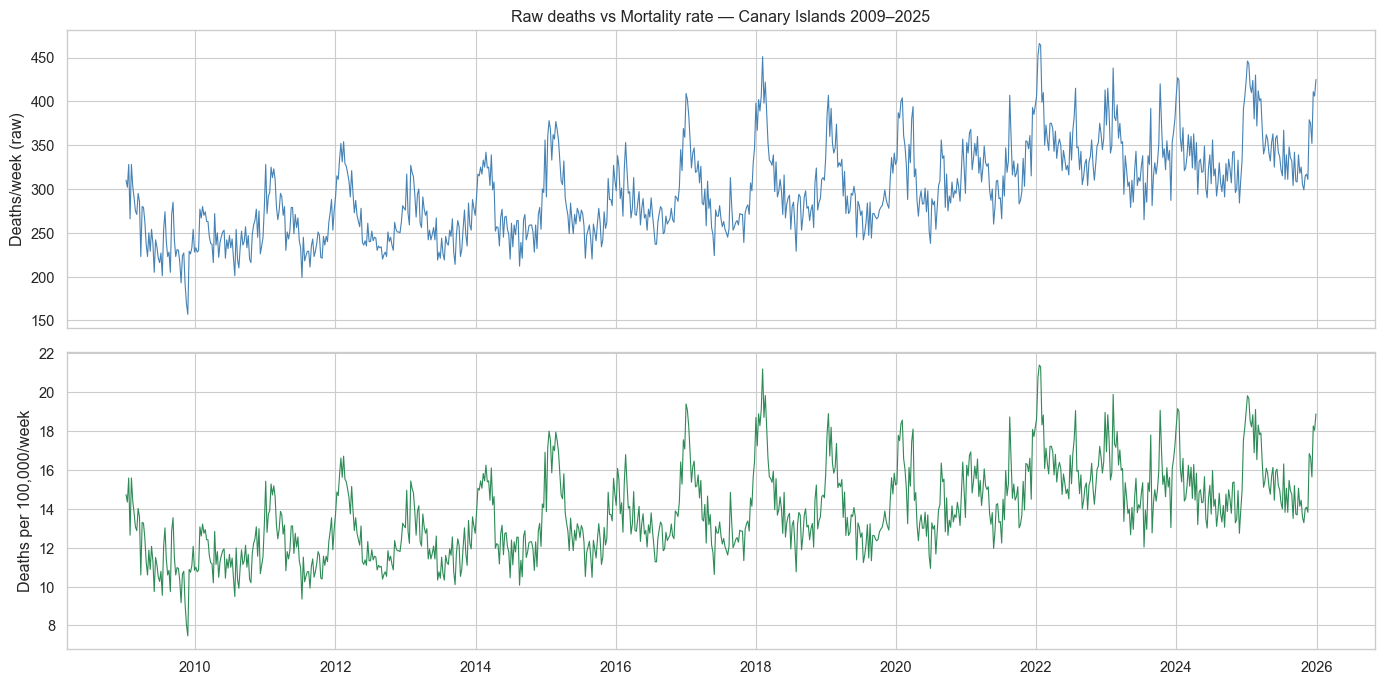

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df_0925['week_start'], df_0925['deaths_week'], linewidth=0.8, color='steelblue')
ax1.set_ylabel('Deaths/week (raw)')
ax1.set_title('Raw deaths vs Mortality rate — Canary Islands 2009–2025')

ax2.plot(df_0925['week_start'], df_0925['mortality_rate'], linewidth=0.8, color='seagreen')
ax2.set_ylabel('Deaths per 100,000/week')

plt.tight_layout()
plt.savefig(r'C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\fig5_mortality_rate.png', dpi=150, bbox_inches='tight')
plt.show()